In [427]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

folder_name = Path(r'C:\Users\Yunxin\Documents\Research\Homer\Data\Spy_GS50_3Homer1_GS160_Avi_1Homer1\20250116')
#figure_path = Path(r'C:\Users\Yunxin Deng\OneDrive - National University of Singapore\Documents\MBI\Research\FilaminC_Ig24\Figures')

In [597]:
file_name = '20250116_Spy_GS50_3Homer1_GS160_Avi_1Homer1_di5_572handle_m270_PTB_23C_bead08_C172_constforce_11'
filename_txt = file_name+".txt"
rawdata = np.loadtxt(folder_name/filename_txt, skiprows=2)
#C = 221

In [637]:
rawTime = rawdata[:,0]
rawMagPos = rawdata[:,1]
rawExt = rawdata[:,2]
ForcePosition = 10.679
F = 7
#ForcePosition = max(rawMagPos)
print(ForcePosition, '\t', F,'pN')

10.679 	 7 pN


In [638]:
cycleflag = 0
newTime = [[]]
newExt = [[]]
datalength = len(rawTime)
for i in range(datalength-1):
  if rawMagPos[i]==ForcePosition:
    if rawMagPos[i+1]!=ForcePosition:
      cycleflag = cycleflag + 1
      newTime.append([])
      newExt.append([])
    else:
      newTime[cycleflag].append(rawTime[i])
      newExt[cycleflag].append(rawExt[i])
#del newTime[-2:-1]
#del newExt[-2:-1]

In [639]:
print(len(newExt))

39


In [640]:
len(newTime)

39

In [641]:
for j in range(len(newTime)-1):
    newTime[j] = newTime[j]-newTime[j][0]

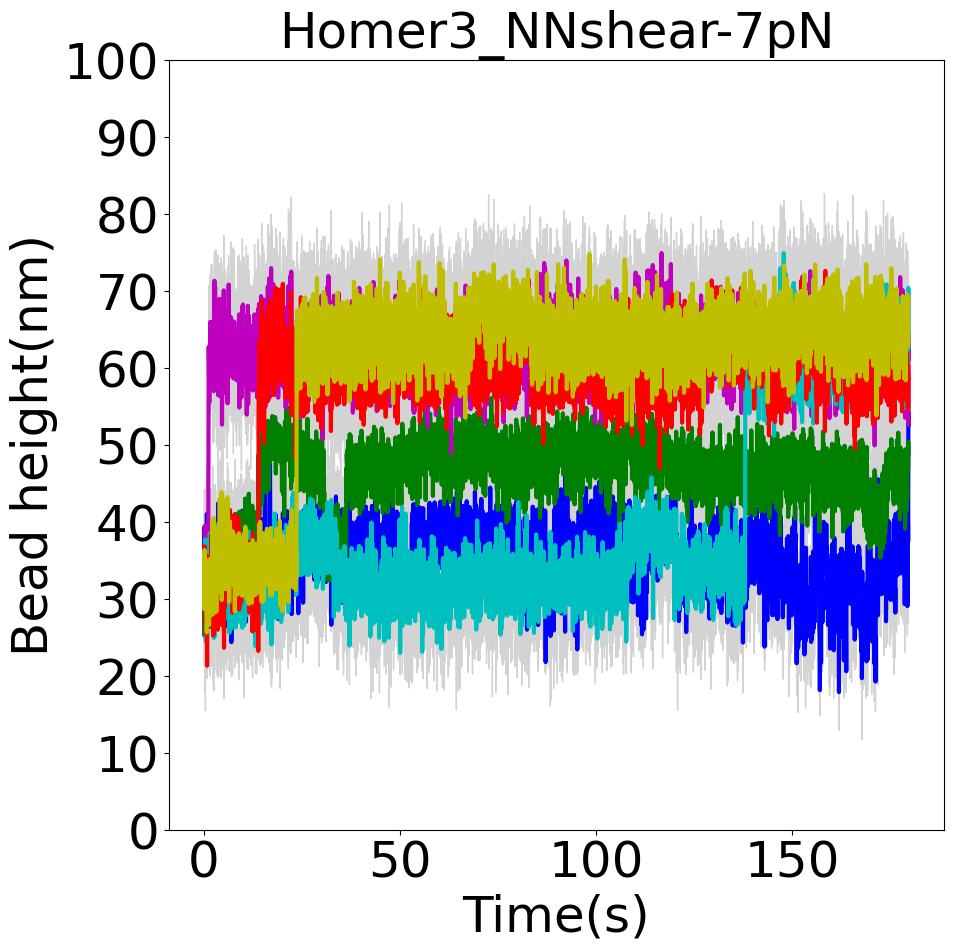

In [642]:
from scipy import fftpack
fig = plt.figure(figsize=[10,10])
#plot_cycle_num = min(4, len(newTime))
plot_cycle_num = np.arange(0,6)
#plot_cycle_num = np.array([0,1,2,3,6,7,9,10,11])
#plot_cycle_num = np.array([10,15,19,25,29])
cycle_choose = 0

colors = ['b','g','m','c','r','y']
for i in plot_cycle_num:
    color_index = np.where(plot_cycle_num == i)
    baseline = (np.mean(newExt[i][0:10])-30)*np.ones(len(newExt[i]))
    sig_fft = fftpack.fft(newExt[i])
    sample_freq = fftpack.fftfreq(len(newExt[i]), d=0.005)
    high_freq_fft = sig_fft.copy()
    high_freq_fft[np.abs(sample_freq) > 10] = 0
    filtered_sig = np.abs(fftpack.ifft(high_freq_fft))
    plt.plot(newTime[i], newExt[i]-baseline, color='lightgrey', linewidth=1, label='Original signal', zorder=0)
    plt.plot(newTime[i][5:-5]-newTime[i][0], filtered_sig[5:-5]-baseline[5:-5], color=colors[color_index[0][0]],linewidth=3, label='Filtered signal', zorder=1)
    #plt.plot(newTime[i][5:-5]-newTime[i][0], filtered_sig[5:-5]-baseline[5:-5], color='m',linewidth=3, label='Filtered signal', zorder=1)
'''sig_fft = fftpack.fft(newExt[cycle_choose])
sample_freq = fftpack.fftfreq(len(newExt[cycle_choose]), d=0.005)
high_freq_fft = sig_fft.copy()
high_freq_fft[np.abs(sample_freq) > 10] = 0
filtered_sig = np.abs(fftpack.ifft(high_freq_fft))'''
#plt.plot(newTime[cycle_choose], newExt[cycle_choose]-baseline, color='lightgrey', linewidth=1, label='Original signal')
#plt.plot(newTime[cycle_choose], filtered_sig-0, color='red',linewidth=2, label='Filtered signal')
plt.ylim(0,100)
#plt.xlim(0,120)
plt.yticks(np.arange(0,105, step=10))
#plt.xticks(np.arange(0,121, step=20))
plt.ylabel('Bead height(nm)', size=36)
plt.xlabel('Time(s)', size=36)
plt.title('Homer3_NNshear-%.dpN'%F, size=36)
plt.tick_params(labelsize=36)
#plt.legend(loc='upper left',framealpha=1, prop = {'size':20},bbox_to_anchor=(1.05, 1))
#plt.savefig(figure_path/'FLNCdimer14pn_curve.eps', format='eps')
plt.show()

(-10.0, 500.0)

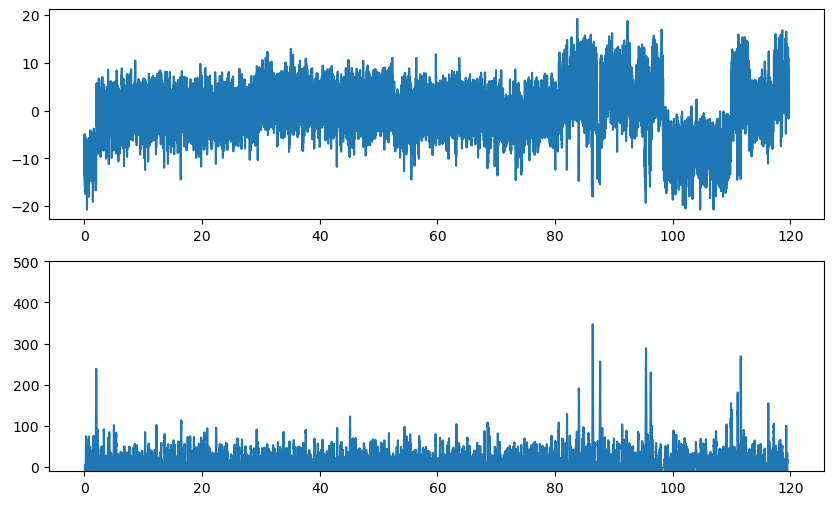

In [629]:
#first cycle, to decide cutoff
n = 0
cut = 20
dary = newExt[n]
dary -= np.average(newExt[n])
step = np.hstack((np.ones(cut), -1*np.ones(cut)))
dary_step = np.convolve(dary, step, mode='same')
fig = plt.figure(figsize=[10,6])
plt.subplot(2,1,1)
plt.plot(newTime[n],dary)
#plt.xlim(20,25)

plt.subplot(2,1,2)
plt.plot(newTime[n],dary_step)
plt.ylim(-10,500)
#plt.yticks(np.arange(-30,70,step=10))

In [ ]:
cutoff = 200 #value can change based on the plot dary_step
step_size = []
step_time = []
cycle_flag = []
for k in range(len(newExt)-1):
  #if k>=28:
    #break
  step_index = []
  step_start = 0
  step_end = 0
  dary = newExt[k]
  dary -= np.average(newExt[k])
  step = np.hstack((np.ones(cut), -1*np.ones(cut)))
  print(k)
  dary_step = np.convolve(dary, step, mode='same')
  dary_step_abs = np.abs(dary_step)
  for i in range(len(dary_step)-cut):
    if np.mean(dary_step_abs[int(i-cut/2):i])<=cutoff and np.mean(dary_step_abs[i:int(i+cut/2)])>cutoff and step_end == 0:
      step_start = i
    if np.mean(dary_step_abs[int(i-cut/2):i])>cutoff and np.mean(dary_step_abs[i:int(i+cut/2)])<=cutoff:
      if step_start != 0:
        step_end = i
        step_index.append(np.argmax(dary_step_abs[step_start:step_end])+step_start)
        step_start = 0
      else:
        step_end = 0
  for j in step_index:
    if newTime[k][j]>0:
        step = np.mean(newExt[k][j:int(j+cut/2)])-np.mean(newExt[k][int(j-cut/2):j])
        if step>0:
            step_size.append(step)
            step_time.append(newTime[k][j])
            cycle_flag.append(k)
print("End")


In [631]:
print(len(cycle_flag))

17


In [632]:
from scipy.optimize import fsolve
contour_length = []
for i in range(len(step_size)):
  def func(x):
    return (x + 1 / (4 * (1 - x) ** 2) - 0.25) * 4.1 / 0.8 - F  # WLC
  sol = fsolve(func, 0.7)
  c_length = step_size[i]/sol[0]
  contour_length.append(c_length)

In [633]:
step_txt = np.vstack((cycle_flag,step_time,step_size,contour_length))
step_txt = np.transpose(step_txt)
head_txt = 'cycle_flag \t step_time(s) \t step_size(nm) \t contour_length(nm) \t date_bead_F \n'

In [634]:
num_str = [str(i) for i in range(10)]
bead_num = []
for i in range(4, len(file_name)):
    if bead_num==[] and file_name[i-4:i]=="bead" and file_name[i]=="0":
        while i<len(file_name) and file_name[i] in num_str:
            bead_num.append(file_name[i])
            i += 1
    if bead_num!=[]:
        bead_label_str = file_name[:8]+"_bead"+"".join(bead_num)
        break
print(bead_label_str+'_%.dpN'%F)

20250116_bead08_9pN


In [635]:
for s1 in step_txt:
    print(['%.2f'%s2 for s2 in s1])

['0.00', '2.02', '11.58', '19.92']
['0.00', '86.39', '19.34', '33.28']
['0.00', '87.66', '13.38', '23.02']
['0.00', '95.46', '13.56', '23.33']
['0.00', '96.26', '11.01', '18.94']
['0.00', '111.56', '16.60', '28.57']
['1.00', '27.47', '30.82', '53.03']
['1.00', '28.52', '16.13', '27.75']
['1.00', '29.49', '16.46', '28.33']
['1.00', '50.70', '18.57', '31.95']
['1.00', '52.13', '15.21', '26.17']
['2.00', '21.00', '33.35', '57.40']
['3.00', '83.13', '31.05', '53.43']
['4.00', '82.59', '33.70', '57.99']
['5.00', '12.41', '36.05', '62.04']
['13.00', '8.02', '38.86', '66.87']
['28.00', '0.60', '10.31', '17.74']


In [636]:
save_file = file_name+"_%.dpN_allsteps.txt"%F
with open(folder_name/save_file, 'w') as file:
    file.write(head_txt)
    # Iterate over both lists together
    for numbers in step_txt:
        # Convert numbers to string and join with the string element
        line = ' '.join(map(str, numbers)) + ' ' + bead_label_str + '_%.dpN'%F + '\n'
        # Write the line to the file
        file.write(line)